In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

In [2]:
# 1. Carga y Preparación del Dataset Transversal (oasis_cross-sectional.csv)
df = pd.read_csv('oasis_cross-sectional.csv') # [8]

# Selección de atributos predictores
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()

# Codificación de Sexo (M=0, F=1) para scikit-learn
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- LINEAMIENTO: Binarización de CDR (2 Clases) ---
# 0 = "non demented" (CDR 0), 1 = "demented" (CDR >= 0.5)
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0) # [5]

# 2. Tratamiento de Datos Faltantes (SES y Educ tienen nulos en este set)
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X) # [9]

/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Ejecutando 10 iteraciones de validación independiente para Regresión Logística...


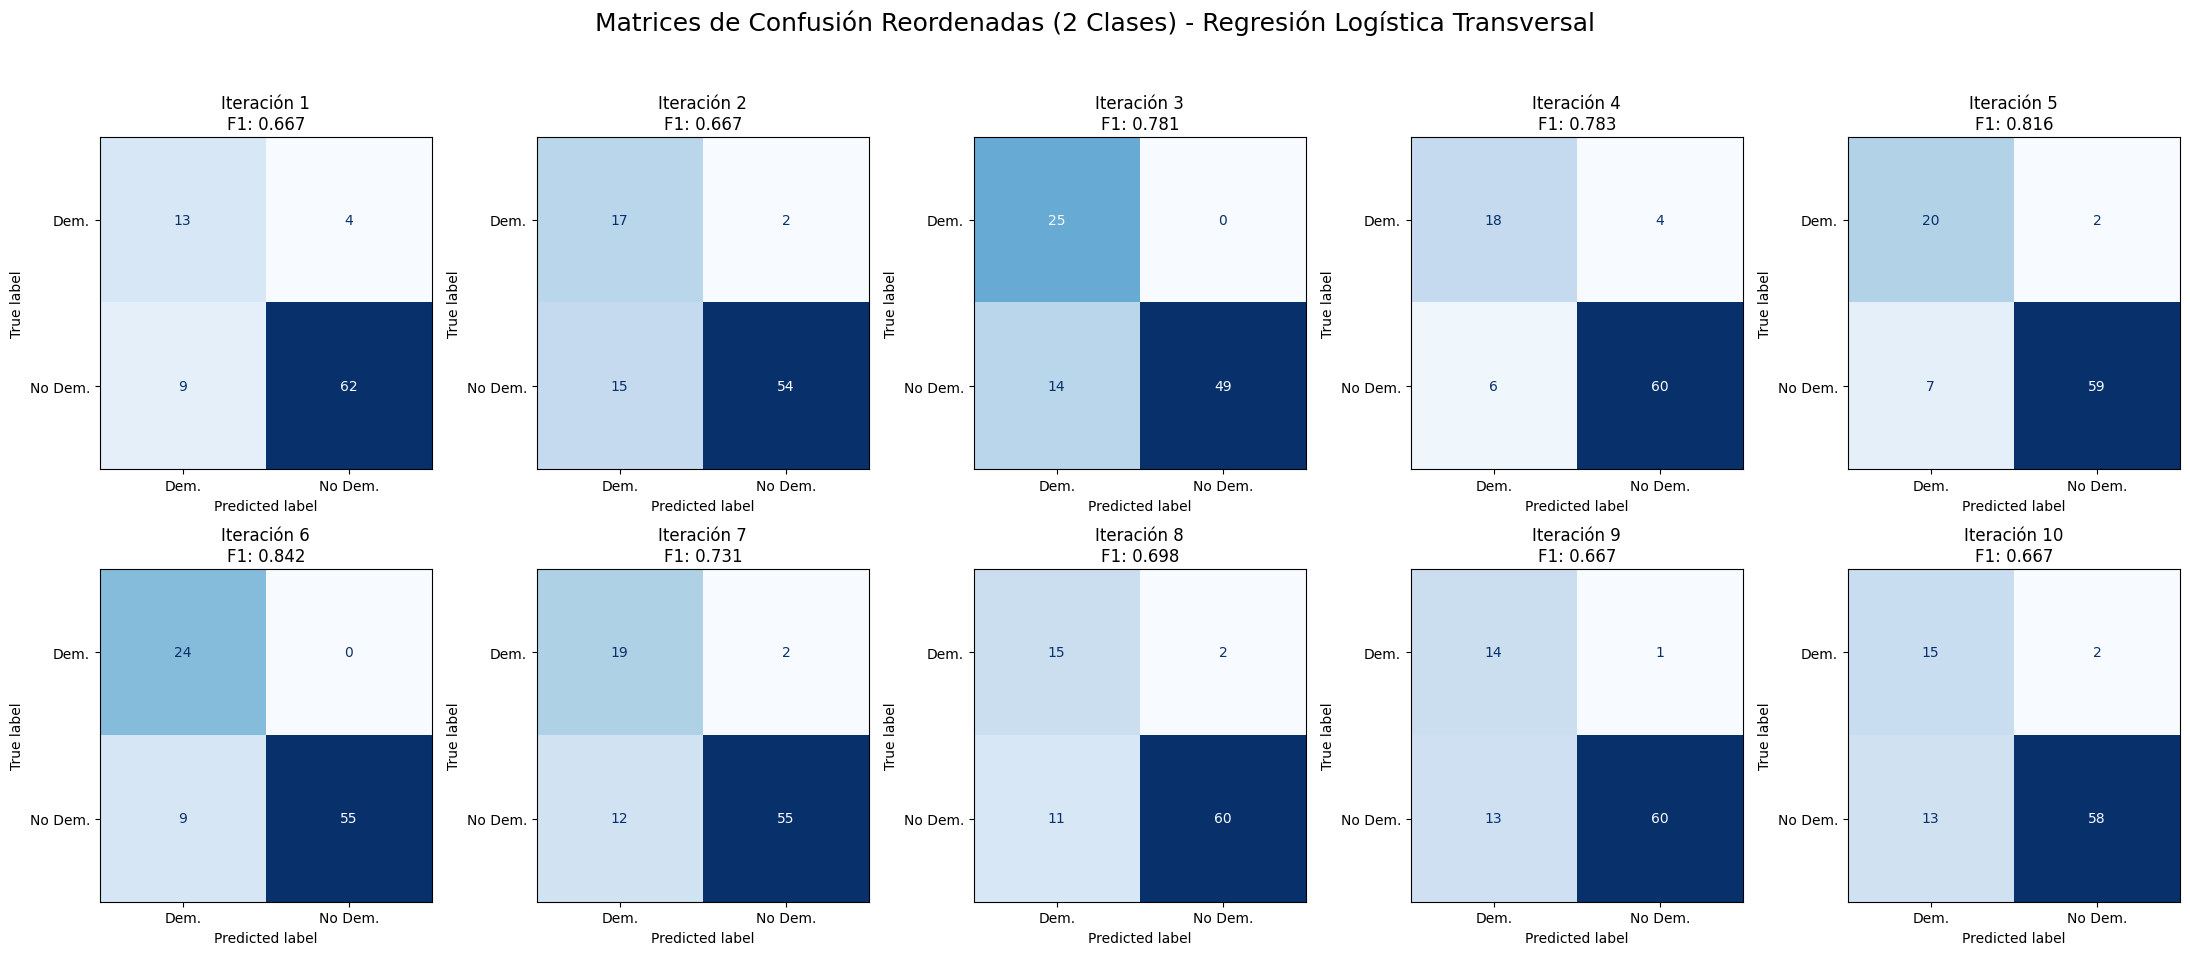

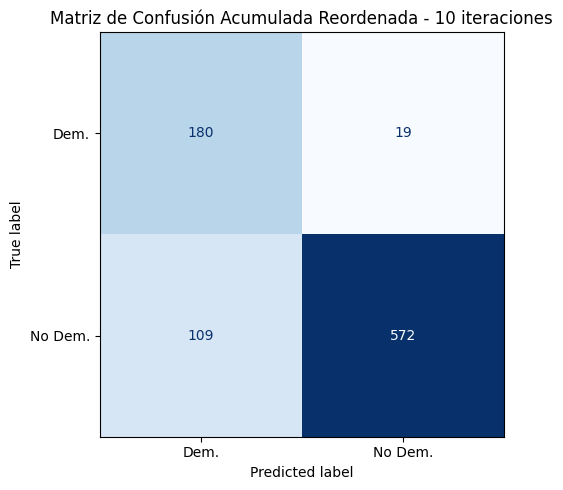


--- DESEMPEÑO FINAL REGRESIÓN LOGÍSTICA (10 ITER) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8545 ± 0.0287
PREC                      | 0.6225 ± 0.0845
REC                       | 0.8990 ± 0.0685
F1                        | 0.7317 ± 0.0652
AUC                       | 0.9566 ± 0.0106


In [3]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para Regresión Logística...")

for i in range(10):
    # Partición aleatoria única por iteración (Sección 12 de la guía)
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito Crítico para Regresión Logística
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración (leakage)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test) # [3, 9]
    
    # 5. Entrenamiento del Modelo de Regresión Logística
    # class_weight='balanced' para mitigar el desbalance natural entre clases
    lr = LogisticRegression(class_weight='balanced', random_state=42)
    lr.fit(X_train_s, y_train)
    
    # Predicciones y probabilidades para AUC
    y_pred = lr.predict(X_test_s)
    y_proba = lr.predict_proba(X_test_s)[:, 1]
    
    # 6. Registro de Métricas de Desempeño (Sección 13 de la guía)
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Generación de Matrices de Confusión por iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión Reordenadas (2 Clases) - Regresión Logística Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# 9. Reporte Final de Desempeño (Media ± DE) [10]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL REGRESIÓN LOGÍSTICA (10 ITER) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)

Ejecutando 10 iteraciones de validación independiente para Regresión Logística...


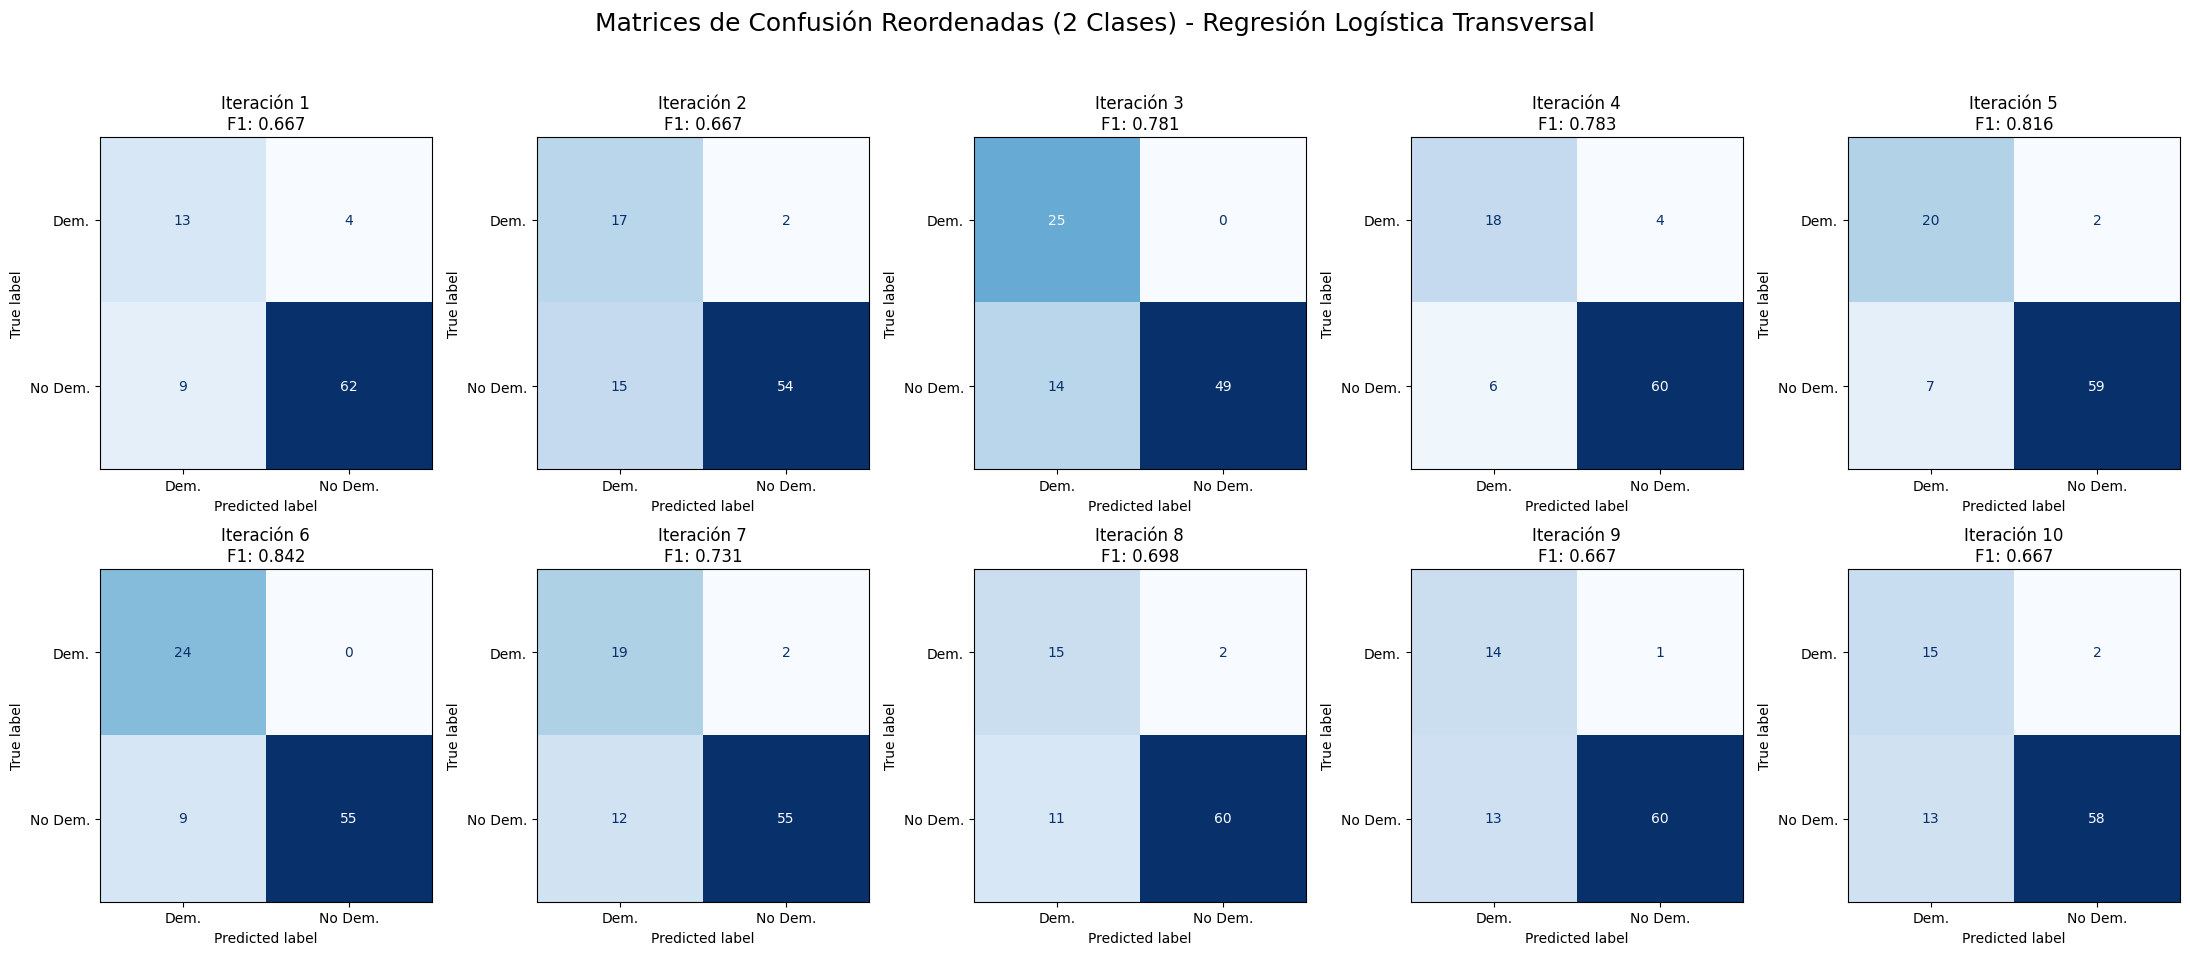

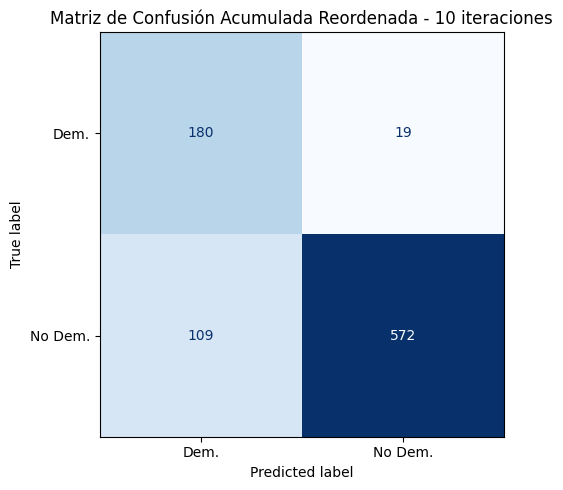


--- DESEMPEÑO FINAL REGRESIÓN LOGÍSTICA (10 ITER) ---
Métrica                   | Promedio ± DE            
-------------------------------------------------------
ACC                       | 0.8545 ± 0.0287
PREC                      | 0.6225 ± 0.0845
REC                       | 0.8990 ± 0.0685
F1                        | 0.7317 ± 0.0652
AUC                       | 0.9566 ± 0.0106


In [4]:
# 3. Diseño Experimental: 10 Validaciones Independientes 80/20
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Ejecutando 10 iteraciones de validación independiente para Regresión Logística...")

for i in range(10):
    # Partición aleatoria única por iteración (Sección 12 de la guía)
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito Crítico para Regresión Logística
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración (leakage)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test) # [3, 9]
    
    # 5. Entrenamiento del Modelo de Regresión Logística
    # class_weight='balanced' para mitigar el desbalance natural entre clases
    lr = LogisticRegression(class_weight='balanced', random_state=42)
    lr.fit(X_train_s, y_train)
    
    # Predicciones y probabilidades para AUC
    y_pred = lr.predict(X_test_s)
    y_proba = lr.predict_proba(X_test_s)[:, 1]
    
    # 6. Registro de Métricas de Desempeño (Sección 13 de la guía)
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Generación de Matrices de Confusión por iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión Reordenadas (2 Clases) - Regresión Logística Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# 9. Reporte Final de Desempeño (Media ± DE) [10]
print("\n" + "="*55)
print(f"--- DESEMPEÑO FINAL REGRESIÓN LOGÍSTICA (10 ITER) ---")
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
for m in results:
    print(f"{m.upper():<25} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*55)

Analizando impacto de la regularización (Parámetro C)...


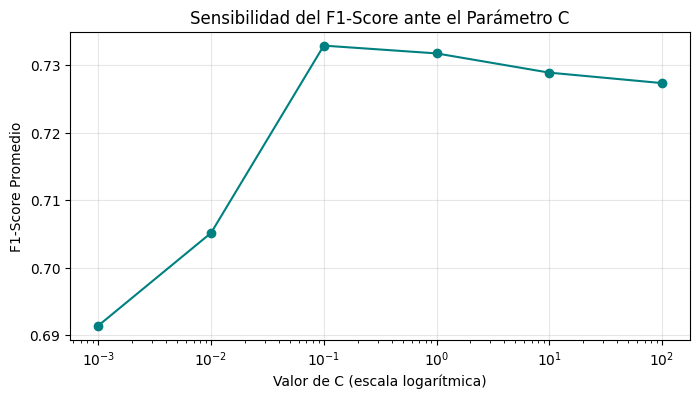

El valor de C recomendado es: 0.1


In [5]:
# Evaluación de la sensibilidad al parámetro C
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
c_results = []

print("Analizando impacto de la regularización (Parámetro C)...")
for c in c_values:
    scores = []
    for i in range(10):
        xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        
        # Escalamiento crítico para convergencia de Regresión Logística [1]
        scaler = StandardScaler()
        xt_s = scaler.fit_transform(xt)
        xv_s = scaler.transform(xv)
        
        # Modelo con penalización L2 (Ridge) por defecto
        lr = LogisticRegression(C=c, class_weight='balanced', solver='liblinear', random_state=42)
        lr.fit(xt_s, yt)
        scores.append(f1_score(yv, lr.predict(xv_s)))
    c_results.append(np.mean(scores))

plt.figure(figsize=(8, 4))
plt.plot(c_values, c_results, marker='o', color='teal')
plt.xscale('log')
plt.title("Sensibilidad del F1-Score ante el Parámetro C")
plt.xlabel("Valor de C (escala logarítmica)")
plt.ylabel("F1-Score Promedio")
plt.grid(True, alpha=0.3)
plt.show()

best_c = c_values[np.argmax(c_results)]
print(f"El valor de C recomendado es: {best_c}")

In [6]:
# Análisis de convergencia
iter_values = range(8-10)
print("\nVerificando convergencia (max_iter)...")
for m in iter_values:
    res = []
    for i in range(10):
        xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        scaler = StandardScaler(); xt_s = scaler.fit_transform(xt); xv_s = scaler.transform(xv)
        
        lr_iter = LogisticRegression(C=best_c, max_iter=m, class_weight='balanced', solver='lbfgs', random_state=42)
        lr_iter.fit(xt_s, yt)
        res.append(lr_iter.score(xv_s, yv))
    print(f"max_iter={m} -> Accuracy promedio: {np.mean(res):.4f}")


Verificando convergencia (max_iter)...



Generando evaluación final con 10 validaciones independientes...


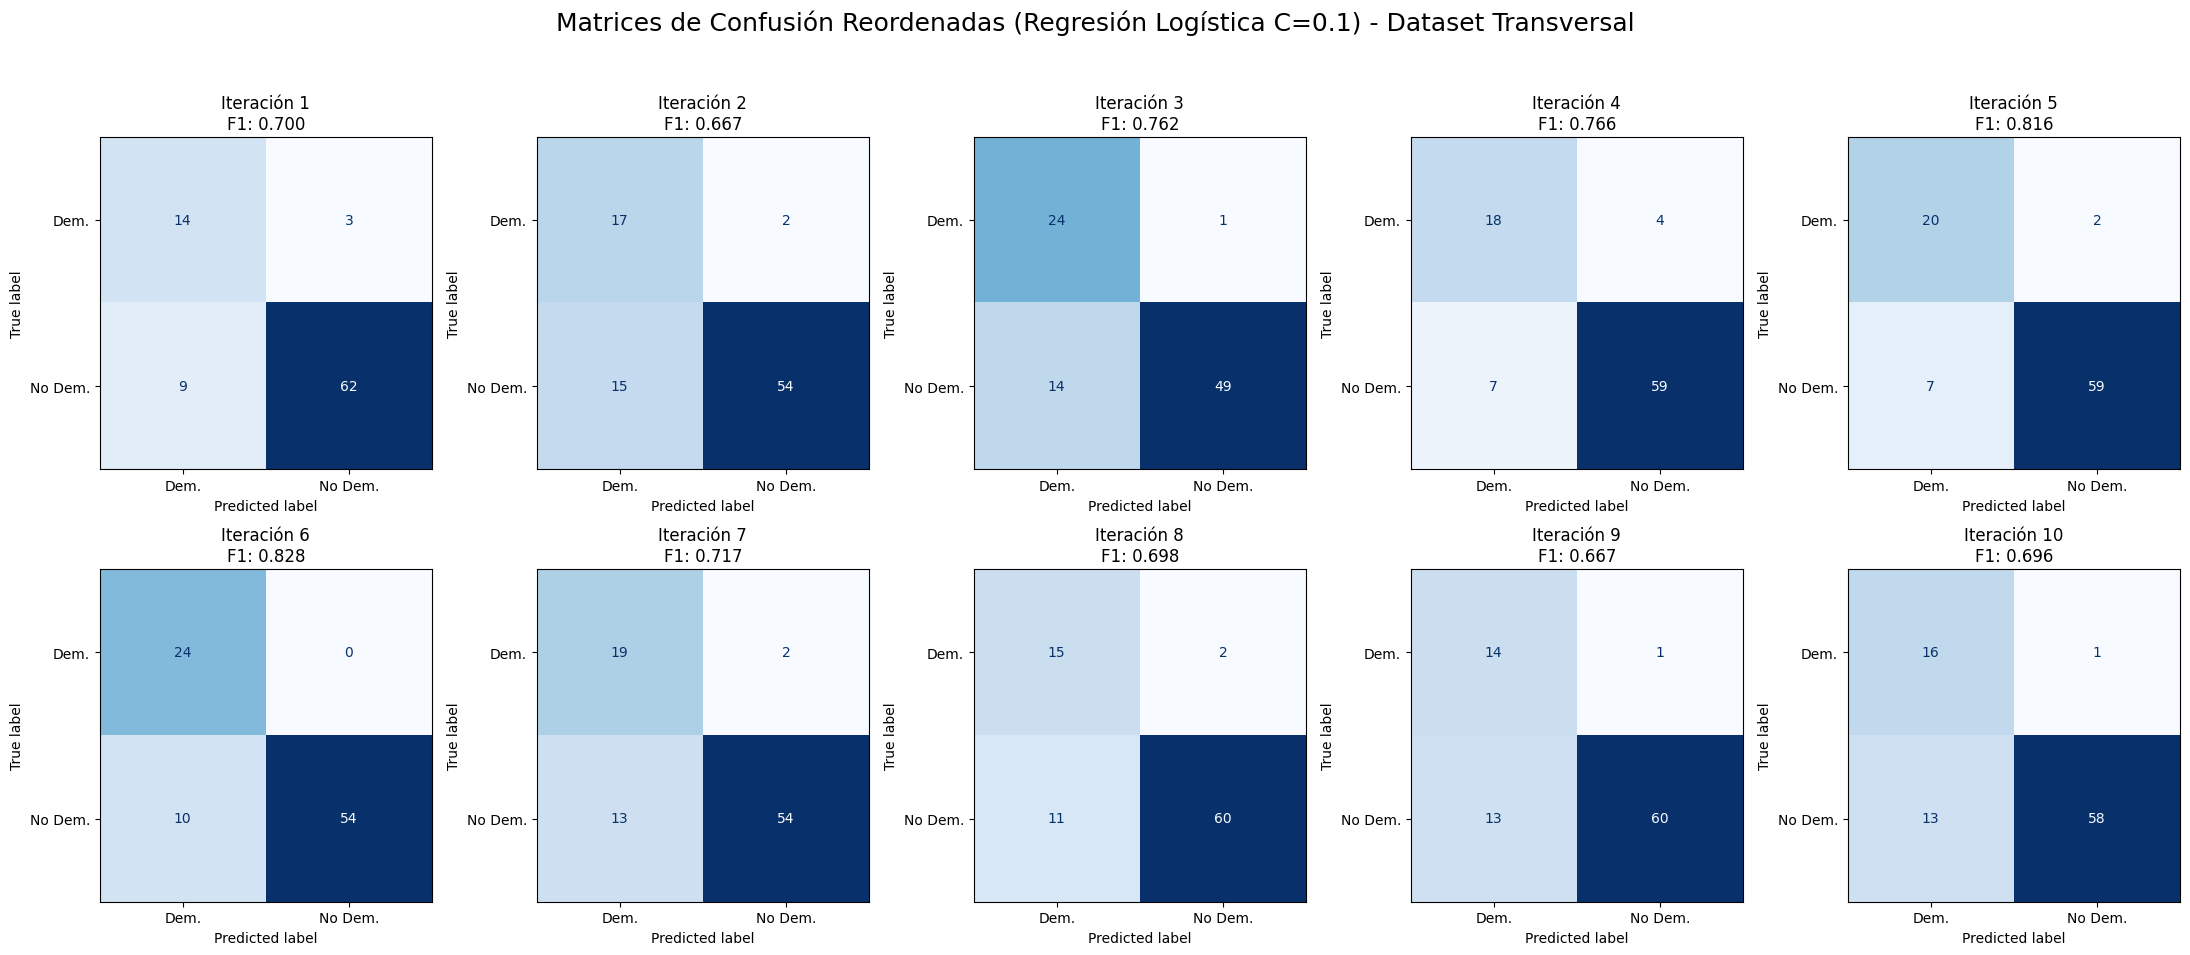

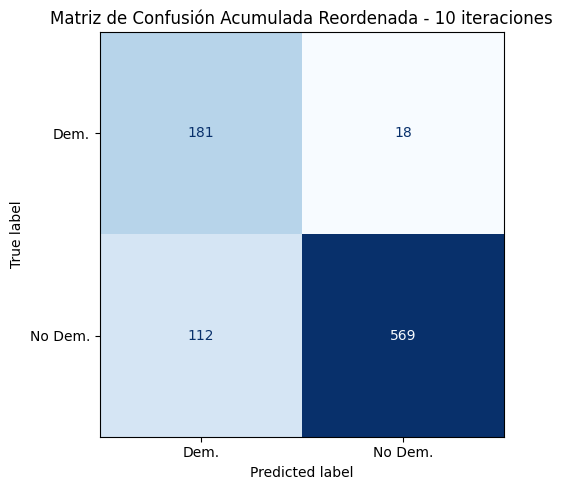


Métrica Final (10 iteraciones)      | Promedio ± DE            
------------------------------------------------------------
ACC                                 | 0.8523 ± 0.0269
PREC                                | 0.6179 ± 0.0759
REC                                 | 0.9067 ± 0.0538
F1                                  | 0.7315 ± 0.0553
AUC                                 | 0.9541 ± 0.0105


In [7]:
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("\nGenerando evaluación final con 10 validaciones independientes...")

for i in range(10):
    # Partición 80/20 independiente
    X_train, X_test, y_train, y_test = train_test_split(X_prep, y, test_size=0.2, random_state=i)
    
    # Escalamiento Z-score ajustado solo en entrenamiento para evitar filtración [6]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo Final Optimizado
    final_lr = LogisticRegression(C=best_c, max_iter=100, class_weight='balanced', random_state=42)
    final_lr.fit(X_train_s, y_train)
    
    y_pred = final_lr.predict(X_test_s)
    y_proba = final_lr.predict_proba(X_test_s)[:, 1]
    
    # Registro de métricas [12]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # Grid de Matrices de Confusión [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle(f"Matrices de Confusión Reordenadas (Regresión Logística C={best_c}) - Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# Reporte Estadístico Final (Sección 12 de la Guía)
print("\n" + "="*60)
print(f"{'Métrica Final (10 iteraciones)':<35} | {'Promedio ± DE':<25}")
print("-" * 60)
for m in results:
    print(f"{m.upper():<35} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*60)


Generando evaluación final con 10 validaciones independientes...


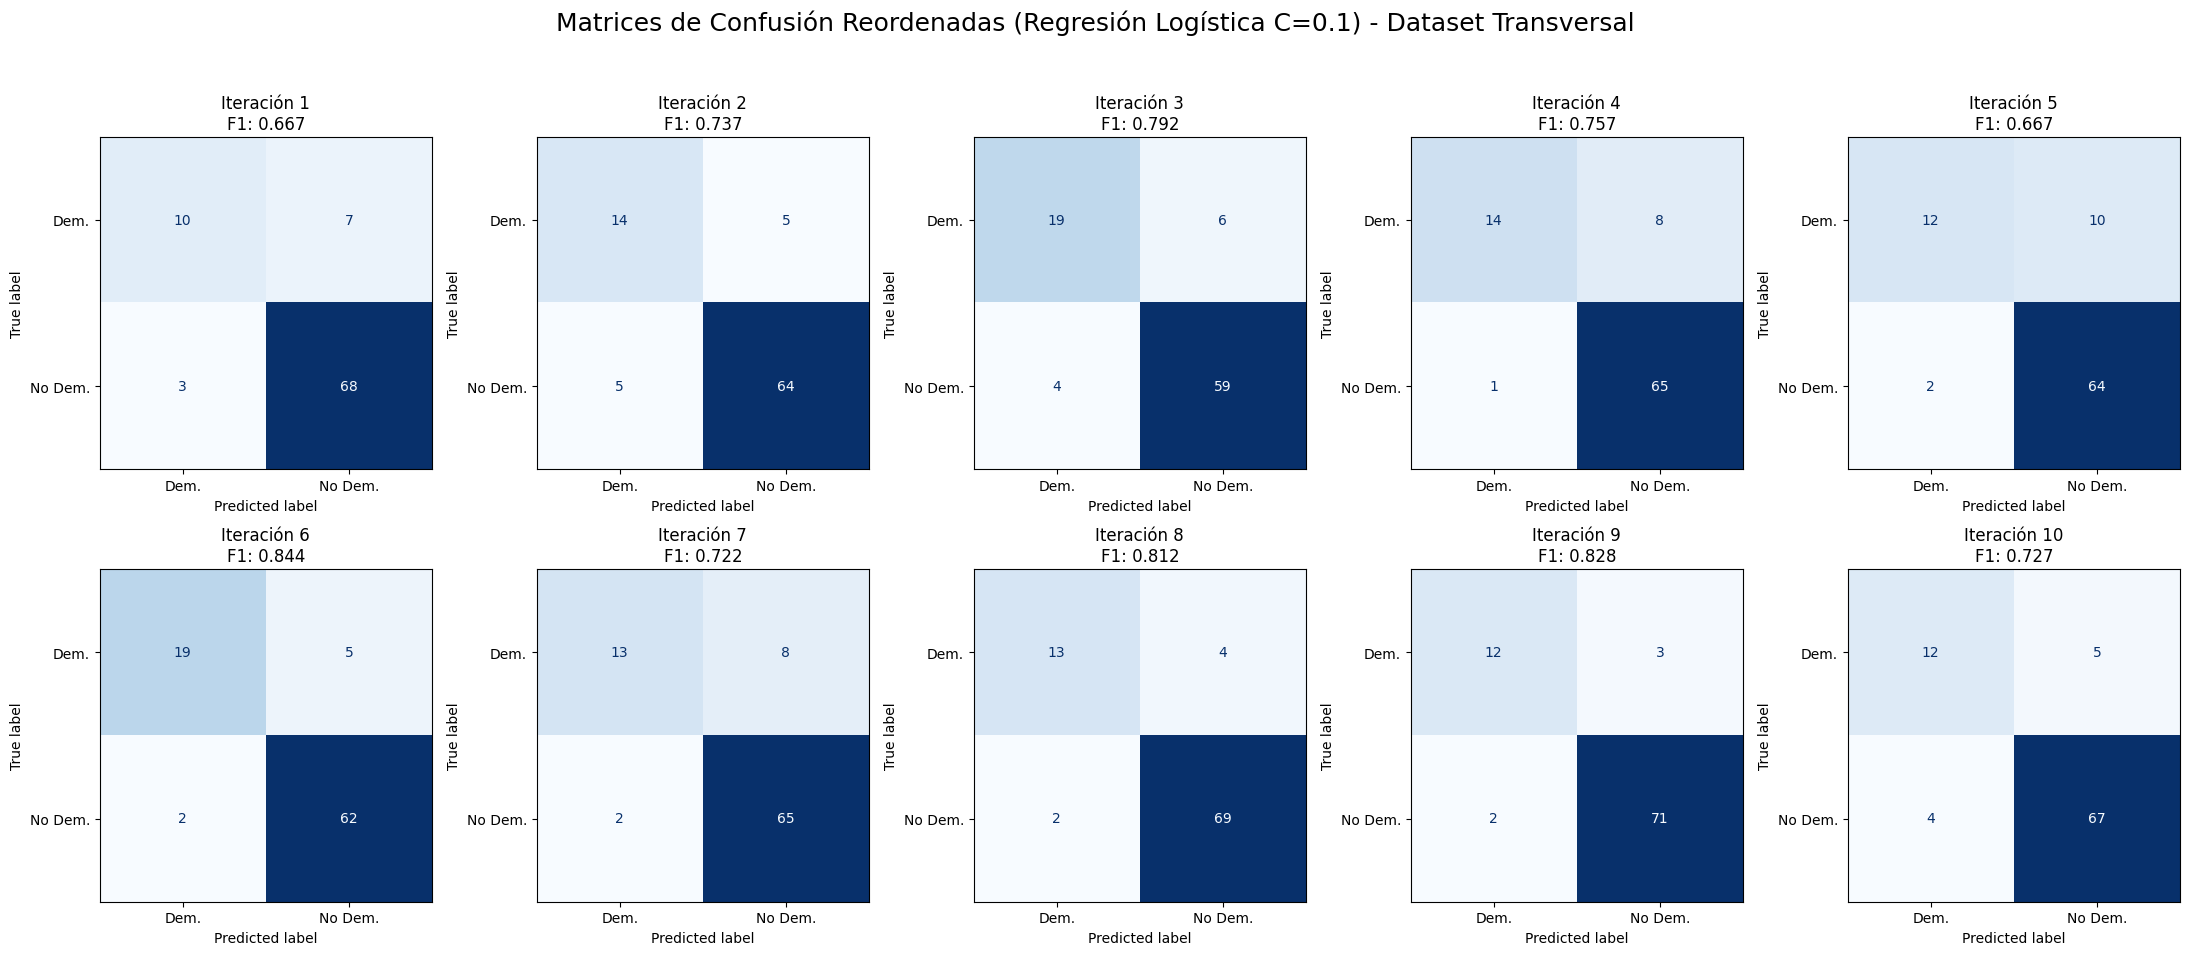

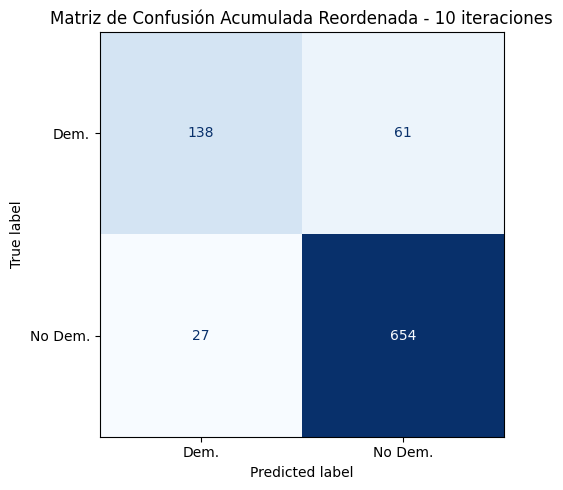


Métrica Final (10 iteraciones)      | Promedio ± DE            
------------------------------------------------------------
ACC                                 | 0.9000 ± 0.0232
PREC                                | 0.8368 ± 0.0623
REC                                 | 0.6948 ± 0.0862
F1                                  | 0.7553 ± 0.0597
AUC                                 | 0.9571 ± 0.0101


In [8]:
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
cm_sum = np.zeros((2, 2), dtype=int)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("\nGenerando evaluación final con 10 validaciones independientes...")

for i in range(10):
    # Partición 80/20 independiente
    X_train, X_test, y_train, y_test = train_test_split(X_prep, y, test_size=0.2, random_state=i)
    
    # Escalamiento Z-score ajustado solo en entrenamiento para evitar filtración [6]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo Final Optimizado
    final_lr = LogisticRegression(C=best_c, max_iter=100, random_state=42)
    final_lr.fit(X_train_s, y_train)
    
    y_pred = final_lr.predict(X_test_s)
    y_proba = final_lr.predict_proba(X_test_s)[:, 1]
    
    # Registro de métricas [12]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # Grid de Matrices de Confusión [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
    cm_sum += cm
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dem.', 'No Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False, values_format='d')
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle(f"Matrices de Confusión Reordenadas (Regresión Logística C={best_c}) - Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Matriz de confusión acumulada sobre las 10 iteraciones
avg_cm = cm_sum
fig_avg, ax_avg = plt.subplots(figsize=(6, 5))
disp_avg = ConfusionMatrixDisplay(confusion_matrix=avg_cm, display_labels=['Dem.', 'No Dem.'])
disp_avg.plot(ax=ax_avg, cmap='Blues', colorbar=False, values_format='d')
ax_avg.set_title('Matriz de Confusión Acumulada Reordenada - 10 iteraciones')
plt.tight_layout()
plt.show()

# Reporte Estadístico Final (Sección 12 de la Guía)
print("\n" + "="*60)
print(f"{'Métrica Final (10 iteraciones)':<35} | {'Promedio ± DE':<25}")
print("-" * 60)
for m in results:
    print(f"{m.upper():<35} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*60)